<a href="https://colab.research.google.com/github/MehulShukla-git/Movie_Recommendation_System/blob/main/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/movies_metadata.csv')

In [ ]:
# df = pd.read_csv('movies_metadata.csv')

In [ ]:
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [ ]:
df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [ ]:
df.shape

(45466, 24)

In [ ]:
df.isnull().sum()

,0
adult,0
belongs_to_collection,40972
budget,0
genres,0
homepage,37684
id,0
imdb_id,17
original_language,11
original_title,0
overview,954


In [ ]:
df = df.drop_duplicates().reset_index(drop = True)

In [ ]:
df = df[['title', 'overview', 'genres','tagline','vote_average','popularity']]

In [ ]:
df

,title,overview,genres,tagline,vote_average,popularity
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",NaN,7.7,21.946943
1,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",Roll the dice and unleash the excitement!,6.9,17.015539
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",Still Yelling. Still Fighting. Still Ready for...,6.5,11.7129
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",Friends are the people who let you be yourself...,6.1,3.859495
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]",Just When His World Is Back To Normal... He's ...,5.7,8.387519
...,...,...,...,...,...,...
45448,Subdue,Rising and falling between a man and woman.,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",Rising and falling between a man and woman,4.0,0.072051
45449,Century of Birthing,An artist struggles to finish his work while a...,"[{'id': 18, 'name': 'Drama'}]",NaN,9.0,0.178241
45450,Betrayal,"When one of her hits goes wrong, a professiona...","[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",A deadly game of wits.,3.8,0.903007
45451,Satan Triumphant,"In a small town live two brothers, one a minis...",[],NaN,0.0,0.003503


In [ ]:
df.isnull().sum()

,0
title,6
overview,954
genres,0
tagline,25045
vote_average,6
popularity,5


In [ ]:
df = df.dropna(subset=['title'])

In [ ]:
df['overview'] = df['overview'].fillna('')

In [ ]:
df.iloc[0]['genres']

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

In [ ]:
"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

In [ ]:
import ast
df['genres'] = df['genres'].apply(lambda x :" ".join([i['name'] for i in ast.literal_eval(x)]))

In [ ]:
df.head()

,title,overview,genres,tagline,vote_average,popularity
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",Animation Comedy Family,NaN,7.7,21.946943
1,Jumanji,When siblings Judy and Peter discover an encha...,Adventure Fantasy Family,Roll the dice and unleash the excitement!,6.9,17.015539
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Romance Comedy,Still Yelling. Still Fighting. Still Ready for...,6.5,11.7129
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Comedy Drama Romance,Friends are the people who let you be yourself...,6.1,3.859495
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Comedy,Just When His World Is Back To Normal... He's ...,5.7,8.387519


In [ ]:
df['tagline'] = df['tagline'].fillna('')

In [ ]:
df.isnull().sum()

,0
title,0
overview,0
genres,0
tagline,0
vote_average,0
popularity,0


In [ ]:
df['tags'] = df['overview']+ " " + df['genres'] +" "+ df['tagline']

In [ ]:
df.head()

,title,overview,genres,tagline,vote_average,popularity,tags
0,Toy Story,"Led by Woody, Andy's toys live happily in his ...",Animation Comedy Family,,7.7,21.946943,"Led by Woody, Andy's toys live happily in his ..."
1,Jumanji,When siblings Judy and Peter discover an encha...,Adventure Fantasy Family,Roll the dice and unleash the excitement!,6.9,17.015539,When siblings Judy and Peter discover an encha...
2,Grumpier Old Men,A family wedding reignites the ancient feud be...,Romance Comedy,Still Yelling. Still Fighting. Still Ready for...,6.5,11.7129,A family wedding reignites the ancient feud be...
3,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",Comedy Drama Romance,Friends are the people who let you be yourself...,6.1,3.859495,"Cheated on, mistreated and stepped on, the wom..."
4,Father of the Bride Part II,Just when George Banks has recovered from his ...,Comedy,Just When His World Is Back To Normal... He's ...,5.7,8.387519,Just when George Banks has recovered from his ...


In [ ]:
df['tags'][1]

"When siblings Judy and Peter discover an enchanted board game that opens the door to a magical world, they unwittingly invite Alan -- an adult who's been trapped inside the game for 26 years -- into their living room. Alan's only hope for freedom is to finish the game, which proves risky as all three find themselves running from giant rhinoceroses, evil monkeys and other terrifying creatures. Adventure Fantasy Family Roll the dice and unleash the excitement!"

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess_text(text):
  #lowercase
  text = str(text).lower()
  #removed the punctuations
  text = re.sub(r'[^a-zA-Z\s]', '', text)

  words = text.split()
  #remove stopwords
  words = [word for word in words if word not in stop_words]

  #lemmatize
  words = [lemmatizer.lemmatize(word) for word in words]

  return " ".join(words)

In [ ]:
df['tags'] = df['tags'].apply(preprocess_text)

In [ ]:
df = df.reset_index(drop = True)

In [ ]:
indices = pd.Series(df.index,index = df['title']).drop_duplicates()
indices

,0
title,
Toy Story,0
Jumanji,1
Grumpier Old Men,2
Waiting to Exhale,3
Father of the Bride Part II,4
...,...
Subdue,45442
Century of Birthing,45443
Betrayal,45444


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(max_features=50000,ngram_range=(1,2),stop_words='english')

In [ ]:
tfidf_matrix = tfidf.fit_transform(df['tags'])

In [ ]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1548114 stored elements and shape (45447, 50000)>


========== 80:20 SPLIT RESULTS ==========

         Metric      Value
0  Accuracy (%)  70.275028
1     Precision   0.277262
2      F1 Score   0.261345
3       ROC AUC   0.536484

========== 70:30 SPLIT RESULTS ==========

         Metric      Value
0  Accuracy (%)  70.172351
1     Precision   0.268522
2      F1 Score   0.251977
3       ROC AUC   0.531896


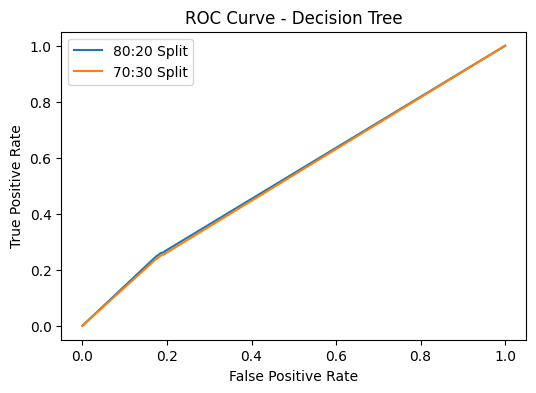


Enter movie name: Toy Story

Recommended Movies:

Toy Story 2
Toy Story 3
Small Fry
Superstar Goofy
Group Sex
What's Up, Tiger Lily?
For Your Consideration
Rebel Without a Cause
Condorman
Malice


In [ ]:
# ==================================
# DECISION TREE MOVIE CLASSIFICATION (80:20 & 70:30)
# ==================================

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# --------------------------------
# STEP 1 : Create Classification Label
# --------------------------------

df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce')
df['label'] = df['vote_average'].apply(lambda x: 1 if x >= 7 else 0)

# --------------------------------
# STEP 2 : Prepare Data
# --------------------------------

X = tfidf_matrix
y = df['label']

# --------------------------------
# FUNCTION TO TRAIN & EVALUATE MODEL
# --------------------------------

def evaluate_model(test_size):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred) * 100
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    return accuracy, precision, f1, roc_auc, y_test, y_prob


# --------------------------------
# STEP 3 : Evaluate for 80:20 Split
# --------------------------------

acc1, pre1, f11, roc1, y_test1, y_prob1 = evaluate_model(0.2)

# --------------------------------
# STEP 4 : Evaluate for 70:30 Split
# --------------------------------

acc2, pre2, f12, roc2, y_test2, y_prob2 = evaluate_model(0.3)

# --------------------------------
# STEP 5 : Create Result Tables
# --------------------------------

table_80_20 = pd.DataFrame({
    "Metric": ["Accuracy (%)", "Precision", "F1 Score", "ROC AUC"],
    "Value": [acc1, pre1, f11, roc1]
})

table_70_30 = pd.DataFrame({
    "Metric": ["Accuracy (%)", "Precision", "F1 Score", "ROC AUC"],
    "Value": [acc2, pre2, f12, roc2]
})

# --------------------------------
# STEP 6 : Print Tables
# --------------------------------

print("\n========== 80:20 SPLIT RESULTS ==========\n")
print(table_80_20)

print("\n========== 70:30 SPLIT RESULTS ==========\n")
print(table_70_30)

# --------------------------------
# STEP 7 : ROC CURVES (Both Splits)
# --------------------------------

fpr1, tpr1, _ = roc_curve(y_test1, y_prob1)
fpr2, tpr2, _ = roc_curve(y_test2, y_prob2)

plt.figure(figsize=(6,4))
plt.plot(fpr1, tpr1, label="80:20 Split")
plt.plot(fpr2, tpr2, label="70:30 Split")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

# --------------------------------
# STEP 8 : Movie Recommendation
# --------------------------------

from sklearn.metrics.pairwise import cosine_similarity

def recommend_movies_dt():

    movie = input("\nEnter movie name: ")

    if movie not in indices:
        print("Movie not found")
        return

    idx = indices[movie]

    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()

    similar_idx = sim_scores.argsort()[::-1][1:11]

    recommendations = df['title'].iloc[similar_idx]

    print("\nRecommended Movies:\n")

    for m in recommendations:
        print(m)

# --------------------------------
# STEP 9 : Run Recommendation
# --------------------------------

recommend_movies_dt()